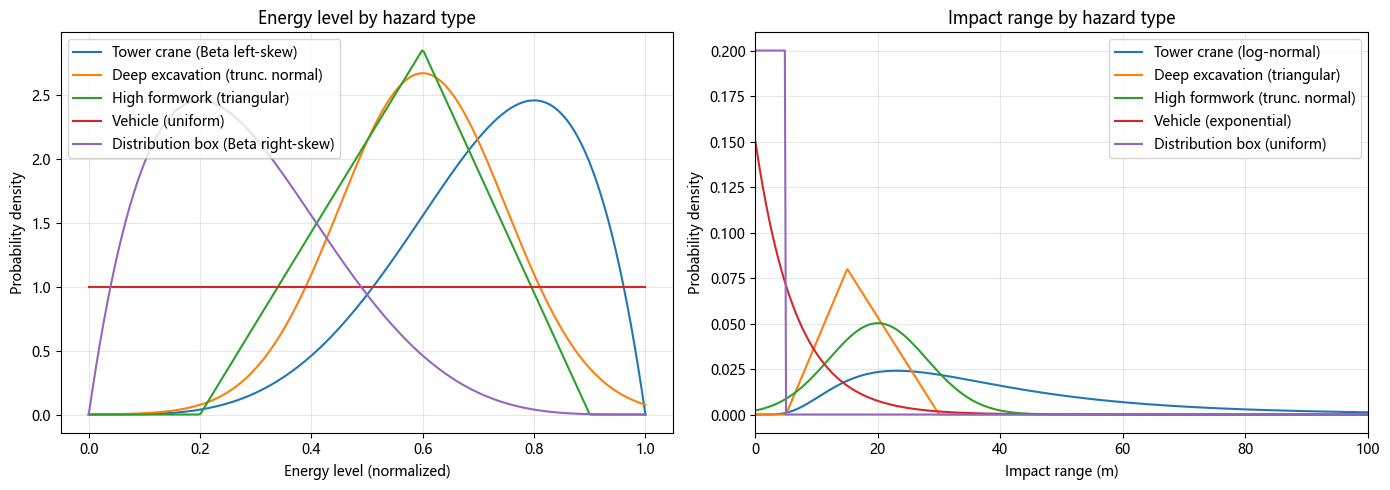

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm, triang, lognorm, expon

# 定义截断正态密度函数
def trunc_norm_pdf(x, mu, sigma, a, b):
    from scipy.stats import norm
    pdf = norm.pdf(x, mu, sigma)
    cdf_a, cdf_b = norm.cdf(a, mu, sigma), norm.cdf(b, mu, sigma)
    return np.where((x>=a)&(x<=b), pdf/(cdf_b-cdf_a), 0)

# ========== 能量等级 (0~1) ==========
x_energy = np.linspace(0, 1, 300)

# 塔吊 (左偏Beta)
pdf_energy_tower = beta.pdf(x_energy, 5, 2)
# 深基坑 (截断正态)
pdf_energy_pit = trunc_norm_pdf(x_energy, 0.6, 0.15, 0, 1)
# 高支模 (三角)
pdf_energy_scaffold = triang.pdf(x_energy, c=(0.6-0.2)/(0.9-0.2), loc=0.2, scale=0.7)
# 车辆 (均匀)
pdf_energy_vehicle = np.ones_like(x_energy)
# 配电箱 (右偏Beta)
pdf_energy_panel = beta.pdf(x_energy, 2, 5)

# ========== 波及范围 (0~100) ==========
x_range = np.linspace(0, 100, 500)

# 塔吊 (对数正态)
pdf_range_tower = lognorm.pdf(x_range, s=0.6, scale=np.exp(3.5))  # 注意：对数正态的scale=exp(μ)
pdf_range_tower[x_range<=0] = 0  # 防止零值
# 深基坑 (三角)
tri_pit = triang(c=(15-5)/(30-5), loc=5, scale=25)  # 注意：scale=b-a
pdf_range_pit = tri_pit.pdf(x_range)
# 高支模 (截断正态)
pdf_range_scaffold = trunc_norm_pdf(x_range, 20, 8, 0, 100)
# 车辆 (指数截断)
lambda_vehicle = 0.15
exp_dist = expon(scale=1/lambda_vehicle)
cdf_100 = exp_dist.cdf(100)
pdf_range_vehicle = exp_dist.pdf(x_range) / cdf_100
# 配电箱 (均匀 0~5)
pdf_range_panel = np.where((x_range>=0)&(x_range<=5), 1/5, 0)

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 左图：能量等级
ax = axes[0]
ax.plot(x_energy, pdf_energy_tower, label='Tower crane (Beta left-skew)')
ax.plot(x_energy, pdf_energy_pit, label='Deep excavation (trunc. normal)')
ax.plot(x_energy, pdf_energy_scaffold, label='High formwork (triangular)')
ax.plot(x_energy, pdf_energy_vehicle, label='Vehicle (uniform)')
ax.plot(x_energy, pdf_energy_panel, label='Distribution box (Beta right-skew)')
ax.set_xlabel('Energy level (normalized)')
ax.set_ylabel('Probability density')
ax.set_title('Energy level by hazard type')
ax.legend()
ax.grid(True, alpha=0.3)

# 右图：波及范围
ax = axes[1]
ax.plot(x_range, pdf_range_tower, label='Tower crane (log-normal)')
ax.plot(x_range, pdf_range_pit, label='Deep excavation (triangular)')
ax.plot(x_range, pdf_range_scaffold, label='High formwork (trunc. normal)')
ax.plot(x_range, pdf_range_vehicle, label='Vehicle (exponential)')
ax.plot(x_range, pdf_range_panel, label='Distribution box (uniform)')
ax.set_xlabel('Impact range (m)')
ax.set_ylabel('Probability density')
ax.set_title('Impact range by hazard type')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()